# GPT1: Improving Language Understanding by Generative Pre-Training

It demonstrates that large gains on diverse tasks such as textual entailment, question answering, semantic similarity assessment, 
and document classification can be realized by generative pre-training of a language model on a diverse corpus of unlabeled text, 
followed by discriminative fine-tuning on each specific task.

In [ ]:
!pip install datasets ftfy spacy seaborn

# Import Libraries

In [1]:
import datasets
import re
import ftfy
import os,csv
import spacy
from collections import Counter,defaultdict
import multiprocessing as mp
import tqdm
import json
import seaborn as sns
import matplotlib.pyplot as plt
from typing import Callable
import torch
from torch.utils.data import DataLoader,Dataset
from torch import nn,optim

In [ ]:
!spacy download en_core_web_md

# Setting important global variables

In [2]:
cpu_cores = os.cpu_count()
end_of_word_token = "</w>"
device = "cuda" if torch.cuda.is_available() else "cpu"
if torch.cuda.is_available():
    num_gpus = torch.cuda.device_count()
    print("Number of GPUs: {num_gpus}")
else:
    print("CUDA is not available")
print(f"Number of CPU cores: {cpu_cores}")

CUDA is not available
Number of CPU cores: 4


# Generative Pre-Training

## Data Prep

### Loading saving and reloading the dataset
We use the BooksCorpus dataset for training the language model. It contains over 7,000 unique unpublished 
books from a variety of genres including Adventure, Fantasy, and Romance. Crucially, it contains long stretches of contiguous 
text, which allows the generative model to learn to condition on long-range information.

In [3]:
# bookscorpus_dataset = datasets.load_dataset("bookcorpus")["train"]
# bookscorpus_dataset.save_to_disk("datasets/bookscorpus")
bookscorpus_dataset = datasets.load_from_disk("datasets/bookscorpus")
len(bookscorpus_dataset), bookscorpus_dataset[0]

(74004228,
 {'text': 'usually , he would be tearing around the living room , playing with his toys .'})

### Cleaning, Saving and Loading cleaned dataset
We use the ftfy library to clean the raw text in BooksCorpus, standardize some punctuation and
whitespace

In [3]:
def clean_text(sentence):
    """
    - uses ftfy library to clean the raw text
    - fixes some issues the spacy tokenizer had on books corpus
    - also does some whitespace standardization
    """
    text = str(sentence["text"])
    text = ftfy.fix_text(text)
    text = text.replace('—', '-')
    text = text.replace('–', '-')
    text = text.replace('―', '-')
    text = text.replace('…', '...')
    text = text.replace('´', "'")
    text = re.sub('''(-+|~+|!+|"+|;+|\?+|\++|,+|\)+|\(+|\\+|\/+|\*+|\[+|\]+|}+|{+|\|+|_+)''', r' \1 ', text)
    text = re.sub('\s*\n\s*', ' \n ', text)
    text = re.sub('[^\S\n]+', ' ', text)
    text = text.strip()
    sentence["text"] = text
    return sentence
# bookscorpus_dataset = bookscorpus_dataset.map(clean_text,num_proc=cpu_cores)
# bookscorpus_dataset.save_to_disk("datasets/bookscorpus_cleaned")
bookscorpus_dataset = datasets.load_from_disk("datasets/bookscorpus_cleaned")
len(bookscorpus_dataset), bookscorpus_dataset[0]

(74004228,
 {'text': 'usually , he would be tearing around the living room , playing with his toys .'})

### Get and save wordcounts(aka vocab)

Uses the spaCy tokenizer to split text. Word counts are important for the byte-pair encoding
- full dataset took 2hrs 20 minutes to count

In [11]:
nlp = spacy.load("en_core_web_md",disable=['parser', 'ner', 'textcat'])

word_counts = Counter()
def split_dataset(size):
    unit = size//cpu_cores
    chunks = []
    for i in range(0,size,unit):
        chunks.append((i,i+unit))
    return chunks

def spacy_tokenize(doc):
    return [" ".join(token.text)+" "+end_of_word_token for token in doc]

def count_words_chunk(chunk):
    start,end = chunk
    local_counts = Counter()
    for doc in tqdm.tqdm(nlp.pipe(bookscorpus_dataset[start:end]),ncols=100):
        words = spacy_tokenize(doc)
        local_counts.update(words)
    return local_counts

with mp.Pool(processes=cpu_cores) as pool:
    chunks = split_dataset(len(bookscorpus_dataset["text"]))  # Implement a way to split the dataset
    chunk_results = pool.map(count_words_chunk, chunks)

    for result in chunk_results:
        word_counts += result

with open("word_counts.json","w") as f:
    json.dump(word_counts,f)

25000it [01:12, 343.36it/s]
25000it [01:14, 335.58it/s]
25000it [01:16, 327.65it/s]
25000it [01:16, 326.72it/s]


In [27]:
with open("word_counts.json", "r") as f:
    word_counts = json.load(f)
len(word_counts),word_counts["he</w>"]

(688442, 13870628)

#### visualize most common and least common words

<Axes: >

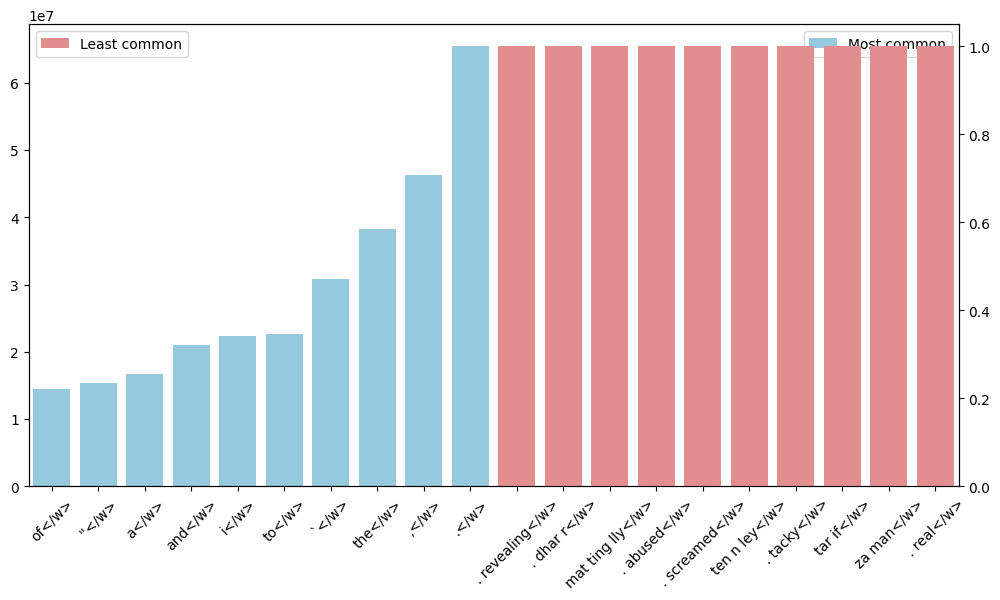

In [6]:
sorted_counts = sorted(word_counts.items(), key=lambda item: item[1])
mc = sorted_counts[-10:]
plt.figure(figsize=(12, 6))
plt.xticks(rotation=45)
sns.barplot(x=[w[0] for w in mc],y=[w[1] for w in mc],color="skyblue",label="Most common")
lc = sorted_counts[:10]
ax2 = plt.twinx()
plt.xticks(rotation=45)
sns.barplot(x=[w[0] for w in lc],y=[w[1] for w in lc],color="lightcoral",label="Least common")

### Train BPE

We used a bytepair encoding (BPE) vocabulary with 40,000 merges. BPE algorithm explained in the (paper)[https://arxiv.org/pdf/1508.07909]

- full bpe training took 10 hrs

In [ ]:
num_merges = 40000

with open("word_counts.json", "r") as f:
    word_counts = json.load(f)
if os.path.exists("encoder.json"):
    with open("encoder.json", "r") as f:
        bpe = list(json.load(f).keys())
else:
    bpe = sorted(list(set(" ".join(word_counts.keys()).split())))
if os.path.exists("bpe.bpe"):
    with open("bpe.bpe", "r") as f:
        tokens = f.read().split("\n")
else:
    tokens = []

def get_stats(vocab):
    pairs = defaultdict(int)
    for word, freq in vocab.items():
        symbols = word.split()
        for i in range(len(symbols)-1):
            pairs[symbols[i],symbols[i+1]] += freq
    return pairs


def merge_vocab(pair, v_in):
    v_out = {}
    bigram = re.escape(' '.join(pair))
    p = re.compile(r'(?<!\S)' + bigram + r'(?!\S)')
    for word in v_in:
        w_out = p.sub(''.join(pair), word)
        v_out[w_out] = v_in[word]
    return v_out


for i in tqdm.tqdm(range(num_merges),ncols=100):
    pairs = get_stats(word_counts)
    best = max(pairs, key=pairs.get)
    word_counts = merge_vocab(best, word_counts)
    if not (len(best[0]) == 1 and best[1] == end_of_word_token):
        bpe.append("".join(best))
        tokens.append("\n"+" ".join(best))
    if i%10 == 0:
        with open("encoder.json","w") as f:
            json.dump({t:i for i,t in enumerate(bpe)},f)
        with open("word_counts.json","w") as f:
            json.dump(word_counts,f)
        with open("bpe.bpe","w") as f:
            f.write("".join(tokens))

In [3]:
if os.path.exists("bpe.json"):
    with open("bpe.json", "r") as f:
        bpe = list(json.load(f).keys())

In [7]:
with open("bpe.bpe","a") as f:
    for t in bpe[68:]:
        f.write(t+"\n")

### Text Encoder

In [4]:
class TextEncoder(object):
    """
        Mostly a wrapper for a public python bpe tokenizer
    """

    def __init__(self, encoder_path, bpe_path, end_of_word_token="</w>"):
        self.nlp = spacy.load('en_core_web_md', disable=['parser', 'ner', 'textcat'])
        self.encoder = json.load(open(encoder_path))
        self.encoder["</padding>"]=len(self.encoder.values())
        self.decoder = {v:k for k,v in self.encoder.items()}
        merges = open(bpe_path).read().split('\n')[1:-1]
        merges = [tuple(merge.split()) for merge in merges]
        self.bpe_ranks = dict(zip(merges, range(len(merges))))
        self.cache = {}
        self.end_of_word_token = end_of_word_token


    def get_pairs(self,word):
        """
        Return set of symbol pairs in a word.
        word is represented as tuple of symbols (symbols being variable-length strings)
        """
        pairs = set()
        prev_char = word[0]
        for char in word[1:]:
            pairs.add((prev_char, char))
            prev_char = char
        return pairs


    def text_standardize(self,text):
        """
        fixes some issues the spacy tokenizer had on books corpus
        also does some whitespace standardization
        """
        text = text.replace('—', '-')
        text = text.replace('–', '-')
        text = text.replace('―', '-')
        text = text.replace('…', '...')
        text = text.replace('´', "'")
        text = re.sub('''(-+|~+|!+|"+|;+|\?+|\++|,+|\)+|\(+|\\+|\/+|\*+|\[+|\]+|}+|{+|\|+|_+)''', r' \1 ', text)
        text = re.sub('\s*\n\s*', ' \n ', text)
        text = re.sub('[^\S\n]+', ' ', text)
        return text.strip()


    def bpe(self, token):
        word = tuple(token[:-1]) + ( token[-1] + self.end_of_word_token,)
        if token in self.cache: #for efficiency
            return self.cache[token]
        pairs = self.get_pairs(word)
        if not pairs: #occurs in case of a one character token like a panctuation
            return token+self.end_of_word_token
        while True:
            bigram = min(pairs, key = lambda pair: self.bpe_ranks.get(pair, float('inf')))
            if bigram not in self.bpe_ranks:
                break
            first, second = bigram
            new_word = []
            i = 0
            while i < len(word):
                try:
                    j = word.index(first, i)
                    new_word.extend(word[i:j])
                    i = j
                except:
                    new_word.extend(word[i:])
                    break
                if word[i] == first and word[i+1] == second and i < len(word)-1:
                    new_word.append(first+second)
                    i += 2
                else:
                    new_word.append(word[i])
                    i += 1
            new_word = tuple(new_word)
            # print(new_word)
            word = new_word
            if len(word) == 1:
                break
            else:
                pairs = self.get_pairs(word)
        word = ' '.join(word)
        if word == '\n  '+self.end_of_word_token:
            word = '\n'+self.end_of_word_token
        self.cache[token] = word
        return word


    def encode(self, text):
        text = self.nlp(self.text_standardize(ftfy.fix_text(text.lower())))
        sentence_tokens,sentence_indices = [],[]
        for spacy_token in text:
            for token in self.bpe(spacy_token.text.lower()).split(' '):
                sentence_tokens.append(token)
                sentence_indices.append(self.encoder.get(token, 0))
        return sentence_tokens,sentence_indices

### Dataloader

In [39]:
class BooksCorpusDataset(Dataset):

    def __init__(self,dataset, start_index:int,end_index:int, context_size=10,te:TextEncoder=None):
        self.dataset = dataset
        self.start_index = start_index
        self.end_index = end_index
        self.context_size = context_size
        self.te = te
        self.current_index=start_index

    def __len__(self):
        return self.end_index-self.start_index

    def __getitem__(self, idx):
        padding_index = self.te.encoder.get("</padding>")
        inputs = []
        tokens = []
        while self.current_index < self.end_index:
            toks,indices = self.te.encode(self.dataset[self.current_index]["text"])
            if (len(inputs)+len(indices)) < self.context_size:
                inputs += indices
                tokens += toks
                self.current_index += 1
            elif len(indices) > self.context_size:
                print(f"Rare case of a sentence size: {len(indices)} longer than context size: {self.context_size}")
                inputs += indices[:self.context_size]
                tokens += toks[:self.context_size]
                self.current_index += 1
            else:
                break
        inputs += [padding_index for _ in range(self.context_size-len(inputs))]
        tokens += ["</padding>" for _ in range(self.context_size-len(tokens))]
        x = torch.tensor(inputs)
        y = torch.tensor(inputs[1:self.context_size+1])

        if y.shape[0] < self.context_size:
            y = torch.cat((y,torch.tensor([padding_index])))
        return x,y

In [61]:
for i,line in enumerate(bookscorpus_dataset):
    print(line["text"])
    if i == 5:
        break
te = TextEncoder("./encoder.json","./bpe.bpe")
n = int(len(bookscorpus_dataset)*.95)
dataset_size = len(bookscorpus_dataset)
training_dataset = BooksCorpusDataset(dataset=bookscorpus_dataset, start_index=0,end_index=n,context_size=512,te=te)
testing_dataset = BooksCorpusDataset(dataset=bookscorpus_dataset,start_index=n,end_index=dataset_size,context_size=512,te=te)
training_dataloader = DataLoader(training_dataset,batch_size=5,shuffle=False)
testing_dataloader = DataLoader(testing_dataset,batch_size=5,shuffle=False)
print(len(training_dataloader))
print(len(testing_dataloader))
x,y = next(iter(training_dataloader))
print(training_dataset.current_index)
print(x.shape)
print()
print(y.shape)
x,y = next(iter(testing_dataloader))
print(testing_dataset.current_index)
print(x.shape)
print()
print(y.shape)

usually , he would be tearing around the living room , playing with his toys .
but just one look at a minion sent him practically catatonic .
that had been megan 's plan when she got him dressed earlier .
he 'd seen the movie almost by mistake , considering he was a little young for the pg cartoon , but with older cousins , along with her brothers , mason was often exposed to things that were older .
she liked to think being surrounded by adults and older kids was one reason why he was a such a good talker for his age .
`` are n't you being a good boy ? ''
14060804
740043
162
torch.Size([5, 512])

torch.Size([5, 512])
70304140
torch.Size([5, 512])

torch.Size([5, 512])


In [44]:
# def tr_data():
#     while training_dataset.current_index < training_dataset:
#         yield next(iter(training_dataloader))

for x,y in training_dataloader:
    print(x.shape)
    break

torch.Size([5, 512])


## Modeling

We use a multi-layer Transformer decoder. This model applies a multi-headed self-attention 
operation over the input context tokens followed by position-wise feedforward layers to produce an output distribution over 
target tokens.  Our model largely follows the original transformer work. We trained a 12-layer decoder-only transformer with 
masked self-attention heads (768 dimensional states and 12 attention heads). For the position-wise feed-forward networks, we used 3072 dimensional inner states. Since layernorm [2] is used extensively throughout the model, a simple weight initialization of
N(0,0.02) was sufficient. We also employed a modified version of L2 regularization proposed in [37], with w = 0.01 on all non bias or
gain weights. For the activation function, we used the Gaussian Error Linear Unit (GELU) [18]. We used learned position embeddings instead of the sinusoidal version proposed in the original work.

<strong> Model details summary </strong>
- number_of_decoder_blocks: 12
- d_model: 768
- position_wise_ff_d_hidden: 3072
- number_of_attention_heads: 12
- activation: GELU
- position_embeddings: learned
- dropout: 0.1

In [46]:
class AttentionHead(nn.Module):
    def __init__(self, embed_dim,head_dim,dropout_rate) -> None:
        super().__init__()
        self.key = nn.Linear(embed_dim,head_dim) # Linear, some use conv1D
        self.query = nn.Linear(embed_dim,head_dim) # Linear, some use conv1D
        self.value = nn.Linear(embed_dim,head_dim) # Linear, some use conv1D
        self.dropout = nn.Dropout(p=dropout_rate)

    def forward(self,x):
        k = self.dropout(self.key(x))
        q = self.dropout(self.query(x))
        v = self.dropout(self.value(x))
        _,T,dk = k.shape
        dot_product_attention = q @ k.transpose(2,1) # MatMul
        scaled_dot_product_attention = dot_product_attention / torch.sqrt(torch.tensor(dk)) # Scale
        masked_scaled_dot_product_attention = scaled_dot_product_attention.masked_fill((torch.tril(torch.ones(T,T)) == 0).to(device),float("-inf")) # Mask
        soft_masked_scaled_dot_product_attention = self.dropout(torch.softmax(masked_scaled_dot_product_attention,dim=-1)) # Softmax
        return soft_masked_scaled_dot_product_attention @ v # MatMul


class MultiHeadAttention(nn.Module):
    def __init__(self,embed_dim,num_heads, head_dim,dropout_rate):
        super().__init__()
        self.heads = nn.ModuleList([AttentionHead(embed_dim,head_dim,dropout_rate=dropout_rate) for _ in range(num_heads)])
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.dropout = nn.Dropout(p=dropout_rate)

    def forward(self,X):
        out = torch.cat([h(X) for h in self.heads],dim=-1) # Concat
        return self.dropout(self.proj(out)) # Linear (proj)


class PositionWiseFeedforward(nn.Module):
    def __init__(self, embed_dim, number_of_hidden_units,dropout_rate) -> None:
        super().__init__()
        self.ffn = nn.Sequential(
            nn.Linear(in_features=embed_dim,out_features=number_of_hidden_units),
            nn.GELU(),
            nn.Linear(in_features=number_of_hidden_units,out_features=embed_dim),
            nn.Dropout(p=dropout_rate),
        )

    def forward(self,X):
        return self.ffn(X)


class DecoderBlock(nn.Module):
    def __init__(self, embed_dim, number_of_hidden_units, num_heads, head_dim,dropout_rate) -> None:
        super().__init__()
        self.mmhsa = MultiHeadAttention(embed_dim,num_heads,head_dim,dropout_rate) #Masked Multi-Head Self-Attention
        self.layer_norm1 = nn.LayerNorm(embed_dim) # MMSA layer norm
        self.pwffn = PositionWiseFeedforward(embed_dim,number_of_hidden_units,dropout_rate) # Positionwise Feedforward Network
        self.layer_norm2 = nn.LayerNorm(embed_dim) # PWFFN layer norm

    def forward(self,X):
        X = self.layer_norm1(X+self.mmhsa(X))
        out = self.layer_norm2(X+self.pwffn(X))
        return out


class GPT1(nn.Module):
    def __init__(self,
                 number_of_decoder_blocks,
                 vocabulary_size,
                 context_size,
                 embed_dim,
                 number_of_hidden_units,
                 num_heads,
                 head_dim,
                 dropout_rate
                ) -> None:
        super().__init__()
        self.context_size = context_size
        self.text_embedding = nn.Embedding(num_embeddings=vocabulary_size,embedding_dim=embed_dim)
        self.position_embedding = nn.Embedding(num_embeddings=context_size,embedding_dim=embed_dim)
        self.embed_dropout = nn.Dropout(p=dropout_rate)
        self.blocks = nn.Sequential(*[DecoderBlock(embed_dim,number_of_hidden_units,num_heads,head_dim,dropout_rate) for _ in range(number_of_decoder_blocks)])
        self.final_layer_norm = nn.LayerNorm(embed_dim)
        self.lm_head = nn.Linear(embed_dim, vocabulary_size)


    def forward(self,X):
        _,T = X.shape
        text_embed = self.embed_dropout(self.text_embedding(X)) # (B,T,C)
        pos_embed = self.embed_dropout(self.position_embedding(torch.arange(T,device=device))) # (T,C)
        X = text_embed + pos_embed # (B,T,C)
        H = self.blocks(X)
        H = self.final_layer_norm(X + H) # (B,T,C)
        logits = self.lm_head(H) # (B,T,vocabulary_size)
        return logits

    def generate(self, current_context, max_new_tokens):
        for _ in range(max_new_tokens): # current_context is (B, T) array of indices in the current context
            current_context_cond = current_context[:, -self.context_size:] # crop current_context to the last context_size tokens
            logits = self(current_context_cond) # get the predictions
            logits = logits[:, -1, :] # focus only on the last time step : becomes (B, C)
            probs = nn.functional.softmax(logits, dim=-1) # apply softmax to get probabilities : becomes (B, C)
            next_token = torch.multinomial(probs, num_samples=1) # sample from the distribution : becomes (B, 1)
            # next_token = torch.argmax(probs,dim=1).unsqueeze(dim=0)
            # print(next_token)
            current_context = torch.cat((current_context, next_token), dim=1) # append sampled index to the running sequence : becomes (B, T+1)
        return current_context


In [62]:
def init_weights(m):
    if isinstance(m, nn.Linear):  # Check if the module is a linear layer
        nn.init.normal_(m.weight, mean=0.0, std=0.02)
        nn.init.zeros_(m.bias)  # Initialize biases to zero
        
model = GPT1(
    number_of_decoder_blocks=12,
    vocabulary_size=len(te.encoder),
    context_size=512,
    embed_dim=768,
    number_of_hidden_units=3072,
    num_heads=12,
    head_dim=64,
    dropout_rate=0.1
)

model = model.to(device)
model = model.apply(init_weights)

from torchsummary import summary
summary(model,verbose=0)

Layer (type:depth-idx)                        Param #
├─Embedding: 1-1                              31,087,872
├─Embedding: 1-2                              393,216
├─Dropout: 1-3                                --
├─Sequential: 1-4                             --
|    └─DecoderBlock: 2-1                      --
|    |    └─MultiHeadAttention: 3-1           2,362,368
|    |    └─LayerNorm: 3-2                    1,536
|    |    └─PositionWiseFeedforward: 3-3      4,722,432
|    |    └─LayerNorm: 3-4                    1,536
|    └─DecoderBlock: 2-2                      --
|    |    └─MultiHeadAttention: 3-5           2,362,368
|    |    └─LayerNorm: 3-6                    1,536
|    |    └─PositionWiseFeedforward: 3-7      4,722,432
|    |    └─LayerNorm: 3-8                    1,536
|    └─DecoderBlock: 2-3                      --
|    |    └─MultiHeadAttention: 3-9           2,362,368
|    |    └─LayerNorm: 3-10                   1,536
|    |    └─PositionWiseFeedforward: 3-11     4,72

In [63]:

def calculate_perplexity(model, dataloader=None):
    model.eval()  # Set the model to evaluation mode
    total_loss = 0
    num_tokens = 0

    with torch.no_grad():
        for i,(X,Y) in enumerate(dataloader):
            logits = model(X)

            # Calculate loss (using cross-entropy loss as an example)
            loss_fct = nn.CrossEntropyLoss(ignore_index = te.encoder.get("</padding>"))  # Ignore padding tokens
            loss = loss_fct(logits.view(-1, logits.size(-1)), X.view(-1))

            total_loss += loss.item() * X.size(1)  # Weight loss by sequence length
            num_tokens += X.size(1)
            if i == 5:
                break

    perplexity = torch.exp(torch.tensor(total_loss) / torch.tensor(num_tokens))
    return perplexity.item()

In [56]:
calculate_perplexity(model=model,dataloader=testing_dataloader)

48524.42578125

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=learning_rate)